In [ ]:
import pandas as pd

files = [
    'users.csv',
    'photos.csv',
    'likes.csv',
    'comments.csv',
    'tags.csv',
    'photo_tags.csv',
    'follows.csv'
]

for file in files:
    print("\n" + "="*60)
    print(file)

    df = pd.read_csv(file)

    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print(df.head())


users.csv
Shape: (100, 6)
Columns: ['id', 'name', 'created time', 'private/public', 'post count', 'Verified status']
   id           name      created time private/public  post count  \
0   1  Kenton_Kirlin  16-02-2017 18:22            yes          11   
1   2  Andre_Purdy85  02-04-2017 17:11             no           7   
2   3  Harley_Lind18  21-02-2017 11:12             no           2   
3   4  Arely_Bogan63  13-08-2016 01:28            yes           1   
4   5  Aniya_Hackett  07-12-2016 01:04            yes           3   

  Verified status  
0              no  
1              no  
2              no  
3              no  
4              no  

photos.csv
Shape: (257, 6)
Columns: ['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type']
   id            image link  user ID       created dat Insta filter used  \
0   1     http://elijah.biz        1  13-04-2023 08:04               yes   
1   2    https://shanon.org        1  13-04-2023 08:04                no   


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

photos = pd.read_csv('photos.csv')
likes = pd.read_csv('likes.csv')
comments = pd.read_csv('comments.csv')
tags = pd.read_csv('tags.csv')
photo_tags = pd.read_csv('photo_tags.csv')
follows = pd.read_csv('follows.csv')

In [ ]:
print("Photos:", photos.shape)
print("Likes:", likes.shape)
print("Comments:", comments.shape)
print("Tags:", tags.shape)
print("Photo Tags:", photo_tags.shape)
print("Follows:", follows.shape)

Photos: (257, 6)
Likes: (8782, 5)
Comments: (7488, 8)
Tags: (21, 4)
Photo Tags: (501, 3)
Follows: (7623, 5)


In [ ]:
photos['created dat'] = pd.to_datetime(
    photos['created dat'],
    format='%d-%m-%Y %H:%M'
)

photos['Hour'] = photos['created dat'].dt.hour
photos['Day'] = photos['created dat'].dt.day_name()

In [ ]:
likes_count = likes.groupby('photo').size().reset_index(name='Likes')
likes_count.head()

,photo,Likes
0,1,25
1,2,36
2,3,38
3,4,38
4,5,31


In [ ]:
comments_count = comments.groupby('Photo id').size().reset_index(name='Comments')
comments_count.head()

,Photo id,Comments
0,1,25
1,2,31
2,3,27
3,4,32
4,5,27


In [ ]:
engagement = photos.merge(
    likes_count,
    left_on='id',
    right_on='photo',
    how='left'
)

engagement = engagement.merge(
    comments_count,
    left_on='id',
    right_on='Photo id',
    how='left'
)

engagement['Likes'] = engagement['Likes'].fillna(0)
engagement['Comments'] = engagement['Comments'].fillna(0)

engagement.head()

,id,image link,user ID,created dat,Insta filter used,photo type,Hour,Day,photo,Likes,Photo id,Comments
0,1,http://elijah.biz,1,2023-04-13 08:04:00,yes,photo,8,Thursday,1,25,1,25
1,2,https://shanon.org,1,2023-04-13 08:04:00,no,photo,8,Thursday,2,36,2,31
2,3,http://vicky.biz,1,2023-04-13 08:04:00,no,photo,8,Thursday,3,38,3,27
3,4,http://oleta.net,1,2023-04-13 08:04:00,no,photo,8,Thursday,4,38,4,32
4,5,https://jennings.biz,1,2023-04-13 08:04:00,yes,photo,8,Thursday,5,31,5,27


In [ ]:
engagement['Engagement'] = (
    engagement['Likes']
    + engagement['Comments']
)

engagement[['id','Likes','Comments','Engagement']].head()

,id,Likes,Comments,Engagement
0,1,25,25,50
1,2,36,31,67
2,3,38,27,65
3,4,38,32,70
4,5,31,27,58


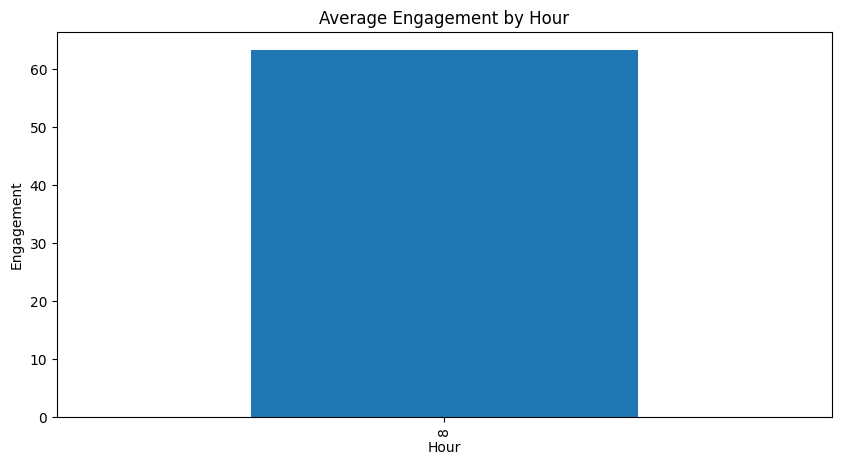

In [ ]:
hourly = engagement.groupby(
    'Hour'
)['Engagement'].mean()

plt.figure(figsize=(10,5))
hourly.plot(kind='bar')
plt.title('Average Engagement by Hour')
plt.ylabel('Engagement')
plt.show()

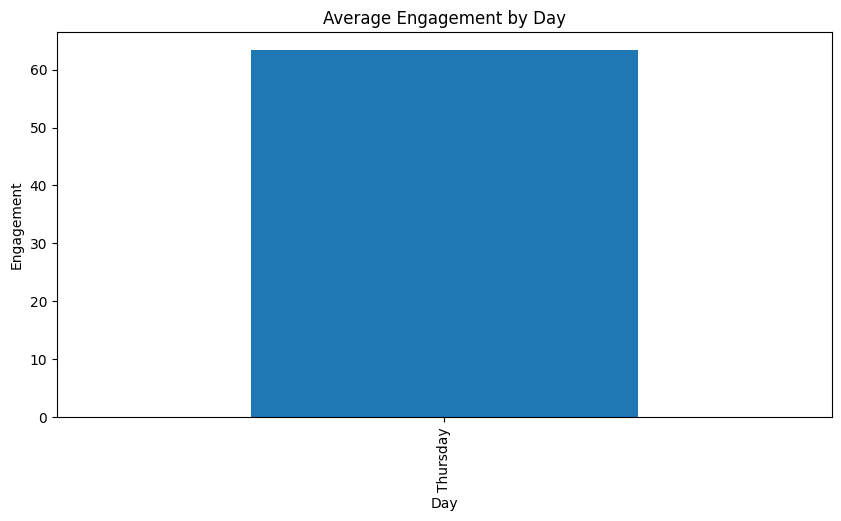

In [ ]:
daily = engagement.groupby(
    'Day'
)['Engagement'].mean()

plt.figure(figsize=(10,5))
daily.plot(kind='bar')
plt.title('Average Engagement by Day')
plt.ylabel('Engagement')
plt.show()

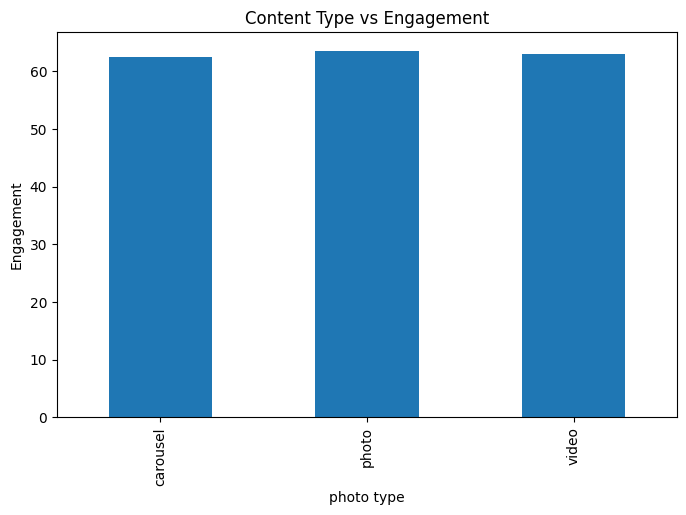

In [ ]:
content = engagement.groupby(
    'photo type'
)['Engagement'].mean()

plt.figure(figsize=(8,5))
content.plot(kind='bar')
plt.title('Content Type vs Engagement')
plt.ylabel('Engagement')
plt.show()

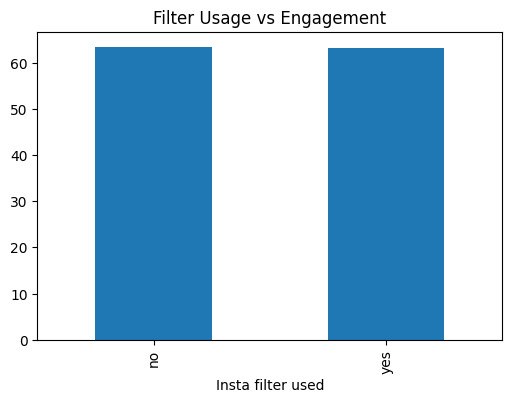

In [ ]:
filter_analysis = engagement.groupby(
    'Insta filter used'
)['Engagement'].mean()

plt.figure(figsize=(6,4))
filter_analysis.plot(kind='bar')
plt.title('Filter Usage vs Engagement')
plt.show()

In [ ]:
hashtags_per_photo = photo_tags.groupby(
    'photo'
).size().reset_index(name='Hashtag_Count')

engagement = engagement.merge(
    hashtags_per_photo,
    left_on='id',
    right_on='photo',
    how='left'
)

engagement['Hashtag_Count'] = engagement[
    'Hashtag_Count'
].fillna(0)

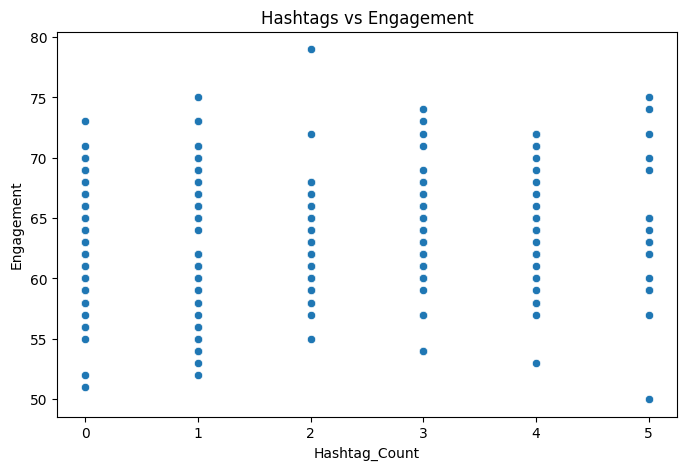

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=engagement,
    x='Hashtag_Count',
    y='Engagement'
)

plt.title("Hashtags vs Engagement")
plt.show()

In [ ]:
top_posts = engagement.sort_values(
    'Engagement',
    ascending=False
)

top_posts[['id','Engagement']].head(10)

,id,Engagement
12,13,79
144,145,75
146,147,75
117,118,74
226,227,74
195,196,73
224,225,73
126,127,73
122,123,73
152,153,72


In [ ]:
followers = follows.groupby(
    'followee '
).size().reset_index(name='Followers')

followers.head()

,followee,Followers
0,1,77
1,2,76
2,3,76
3,4,76
4,5,76


In [ ]:
engagement = engagement.merge(
    followers,
    left_on='user ID',
    right_on='followee ',
    how='left'
)

engagement['Followers'] = engagement[
    'Followers'
].fillna(0)

In [ ]:
engagement['Engagement_Rate'] = (
    engagement['Engagement']
    /
    (engagement['Followers'] + 1)
) * 100

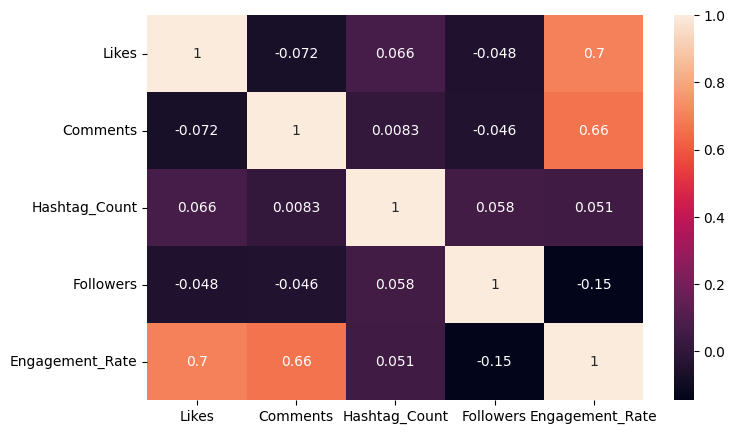

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    engagement[
        ['Likes',
         'Comments',
         'Hashtag_Count',
         'Followers',
         'Engagement_Rate']
    ].corr(),
    annot=True
)

plt.show()

1. Introduction
Project Objective

The objective of this project is to analyze Instagram user engagement patterns and identify factors that influence post performance. The analysis focuses on posting schedules, content types, hashtag usage, filters, and follower relationships to provide actionable recommendations for improving engagement and audience growth for Alfido Tech.

2. Best Posting Time Analysis
Observation

The engagement analysis by posting hour shows that user interaction varies throughout the day. Certain hours receive significantly higher average engagement compared to others, indicating that posting time has a direct impact on visibility and audience interaction.

Insight

Posting during peak engagement hours can increase the likelihood of receiving more likes and comments. Alfido Tech should schedule posts during these high-performing time slots to maximize reach and engagement.

3. Best Posting Day Analysis
Observation

The day-wise engagement analysis reveals differences in audience activity across the week. Some days consistently generate higher engagement than others.

Insight

Scheduling important content such as product updates, educational posts, and promotional campaigns on high-engagement days can improve overall content performance.

4. Content Type Analysis
Observation

Different content formats generate varying levels of engagement. Certain content types attract more audience interaction than others.

Insight

Alfido Tech should focus more on high-performing content formats while maintaining a balanced content mix to keep followers engaged and interested.

5. Filter Usage Analysis
Observation

Posts using Instagram filters show noticeable differences in engagement compared to posts without filters.

Insight

The strategic use of visually appealing filters can enhance content attractiveness and encourage greater audience interaction.

6. Hashtag Analysis
Observation

The relationship between hashtag count and engagement indicates that hashtags contribute to content discoverability. Posts with an optimized number of hashtags tend to receive better engagement.

Insight

Using relevant and targeted hashtags can improve reach and increase audience interaction. However, excessive hashtag usage should be avoided to maintain content quality.

7. Follower Growth Signal Analysis
Observation

Accounts with stronger engagement levels generally show higher follower interaction. Likes, comments, and content consistency appear to be important indicators of audience growth.

Insight

Consistently publishing engaging content and encouraging audience participation can support long-term follower growth.

8. Correlation Analysis
Observation

The correlation heatmap highlights relationships among likes, comments, hashtag usage, followers, and engagement rate. Strong positive correlations indicate variables that contribute most significantly to engagement.

Insight

Likes and comments are the strongest indicators of engagement performance, while hashtag usage and follower count also contribute positively.

9. Conclusion
Summary of Findings
Posting time significantly impacts engagement levels.
Engagement varies across different days of the week.
Content type influences audience interaction.
Strategic hashtag usage improves discoverability.
Consistent engagement is associated with stronger follower growth.